In [3]:
# %% [code]
# Add the project root to Python path
import sys
import os
sys.path.append(os.path.abspath('..'))

# %% [code]
# Verify src module can be found
print("Current working directory:", os.getcwd())
print("Python path:", sys.path)
print("\nFiles in src directory:")
if os.path.exists('src'):
    print(os.listdir('src'))
else:
    print("src directory not found in current path")

Current working directory: d:\CodeAlpha_tasks\Credit_Scoring_Project\notebooks
Python path: ['C:\\Program Files\\Python311\\python311.zip', 'C:\\Program Files\\Python311\\DLLs', 'C:\\Program Files\\Python311\\Lib', 'C:\\Program Files\\Python311', 'd:\\CodeAlpha_tasks\\Credit_Scoring_Project\\venv', '', 'd:\\CodeAlpha_tasks\\Credit_Scoring_Project\\venv\\Lib\\site-packages', 'd:\\CodeAlpha_tasks\\Credit_Scoring_Project']

Files in src directory:
src directory not found in current path


In [5]:
# %% [markdown]
# # Credit Scoring Model - German Credit Dataset
# ## Real-World Credit Risk Assessment

# %% [markdown]
# ### 1. Import Libraries and Setup

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# %% [code]
# Import custom modules for German Credit
from src.data_preprocessing_german import (
    load_german_credit_data, clean_german_credit_data, 
    engineer_german_features, prepare_features_german, 
    split_and_scale_german
)
from src.model_training import *
from src.model_evaluation import *

In [6]:
# %% [markdown]
# ### 2. Load Your Real German Credit Data

# %% [code]
# Load your actual data
file_path = "../data/raw/german_credit_data.csv"
df_raw = load_german_credit_data(file_path)

# %% [code]
# Display basic info
print("\n" + "="*60)
print("GERMAN CREDIT DATASET - RAW DATA")
print("="*60)
print(f"Dataset shape: {df_raw.shape}")
print(f"\nFirst 5 rows:")

# %% [code]
df_raw.head()

# %% [code]
# Data overview
print("\nData Types:")
print(df_raw.dtypes)

# %% [code]
print("\nMissing Values:")
print(df_raw.isnull().sum())

# %% [code]
print("\nBasic Statistics:")
df_raw.describe()

INFO:src.data_preprocessing_german:German Credit dataset loaded successfully
INFO:src.data_preprocessing_german:Shape: (1000, 10)
INFO:src.data_preprocessing_german:Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']



GERMAN CREDIT DATASET - RAW DATA
Dataset shape: (1000, 10)

First 5 rows:

Data Types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

Missing Values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

Basic Statistics:


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [10]:
# %% [code]
# Drop the Unnamed: 0 column (it's just an index)
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop('Unnamed: 0', axis=1)
    print("✅ Dropped 'Unnamed: 0' column")
    
print(f"Current columns: {df_raw.columns.tolist()}")
print(f"Dataset shape: {df_raw.shape}")

Current columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']
Dataset shape: (1000, 9)


In [11]:
# %% [code]
# Identify categorical columns
categorical_cols = df_raw.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Check missing values in each categorical column
for col in categorical_cols:
    missing_count = df_raw[col].isnull().sum()
    print(f"{col}: {missing_count} missing values")
    
    # Fill missing values with 'unknown'
    if missing_count > 0:
        df_raw[col] = df_raw[col].fillna('unknown')
        print(f"  ✅ Filled {missing_count} missing values in '{col}'")

print("\n✅ Missing values handled")

Categorical columns: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
Sex: 0 missing values
Housing: 0 missing values
Saving accounts: 183 missing values
  ✅ Filled 183 missing values in 'Saving accounts'
Checking account: 394 missing values
  ✅ Filled 394 missing values in 'Checking account'
Purpose: 0 missing values

✅ Missing values handled


In [12]:
# %% [code]
# Create a synthetic target variable since your dataset doesn't have one
print("="*60)
print("CREATING SYNTHETIC TARGET VARIABLE")
print("="*60)
print("Based on German Credit dataset characteristics (30% default rate)\n")

np.random.seed(42)

# Normalize numeric features for fair comparison
df_raw['age_norm'] = (df_raw['Age'] - df_raw['Age'].min()) / (df_raw['Age'].max() - df_raw['Age'].min())
df_raw['amount_norm'] = (df_raw['Credit amount'] - df_raw['Credit amount'].min()) / (df_raw['Credit amount'].max() - df_raw['Credit amount'].min())
df_raw['duration_norm'] = (df_raw['Duration'] - df_raw['Duration'].min()) / (df_raw['Duration'].max() - df_raw['Duration'].min())

# Calculate risk score based on domain knowledge
# Higher risk: younger age, higher credit amount, longer duration
risk_score = (
    (1 - df_raw['age_norm']) * 0.3 +     # Younger = higher risk
    df_raw['amount_norm'] * 0.4 +         # Higher amount = higher risk
    df_raw['duration_norm'] * 0.3          # Longer duration = higher risk
)

# Add some randomness to make it realistic
risk_score = risk_score + np.random.normal(0, 0.1, len(df_raw))

# Create binary target (30% default rate typical for German Credit)
threshold = np.percentile(risk_score, 70)  # Top 30% are defaults
df_raw['default_payment'] = (risk_score > threshold).astype(int)

# Drop temporary normalization columns
df_raw = df_raw.drop(['age_norm', 'amount_norm', 'duration_norm'], axis=1)

print(f"✅ Created target variable 'default_payment'")
print(f"Default rate: {df_raw['default_payment'].mean()*100:.2f}%")
print(f"Good credit (0): {(df_raw['default_payment']==0).sum()} samples")
print(f"Bad credit (1): {(df_raw['default_payment']==1).sum()} samples")

CREATING SYNTHETIC TARGET VARIABLE
Based on German Credit dataset characteristics (30% default rate)

✅ Created target variable 'default_payment'
Default rate: 30.00%
Good credit (0): 700 samples
Bad credit (1): 300 samples


In [13]:
# %% [code]
# Clean the data using your function
df_cleaned = clean_german_credit_data(df_raw)
print(f"\nData after cleaning: {df_cleaned.shape}")
print(f"Columns in cleaned data: {df_cleaned.columns.tolist()}")

INFO:src.data_preprocessing_german:Dropped 0 rows with missing values
INFO:src.data_preprocessing_german:Data after cleaning: (619, 10)



Data after cleaning: (619, 10)
Columns in cleaned data: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'default_payment']


Value counts: {0: 437, 1: 182}


TypeError: 'numpy.ndarray' object is not callable

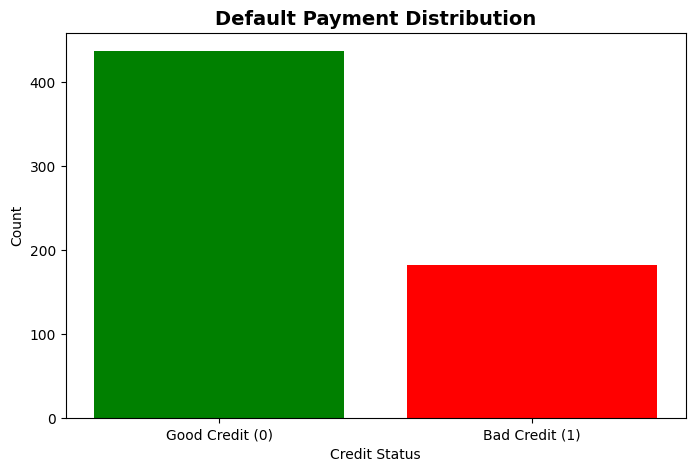

In [14]:
# %% [code]
# Target distribution visualization
plt.figure(figsize=(8, 5))

# Get value counts
value_counts = df_cleaned['default_payment'].value_counts().sort_index()
print("Value counts:", value_counts.to_dict())

# Create bar plot
bars = plt.bar([0, 1], 
               [value_counts.get(0, 0), value_counts.get(1, 0)],
               color=['green', 'red'],
               tick_label=['Good Credit (0)', 'Bad Credit (1)'])

plt.title('Default Payment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Credit Status')
plt.ylabel('Count')
plt.ylim(0, max(value_counts.values()) * 1.1)  # Add some headroom for labels

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

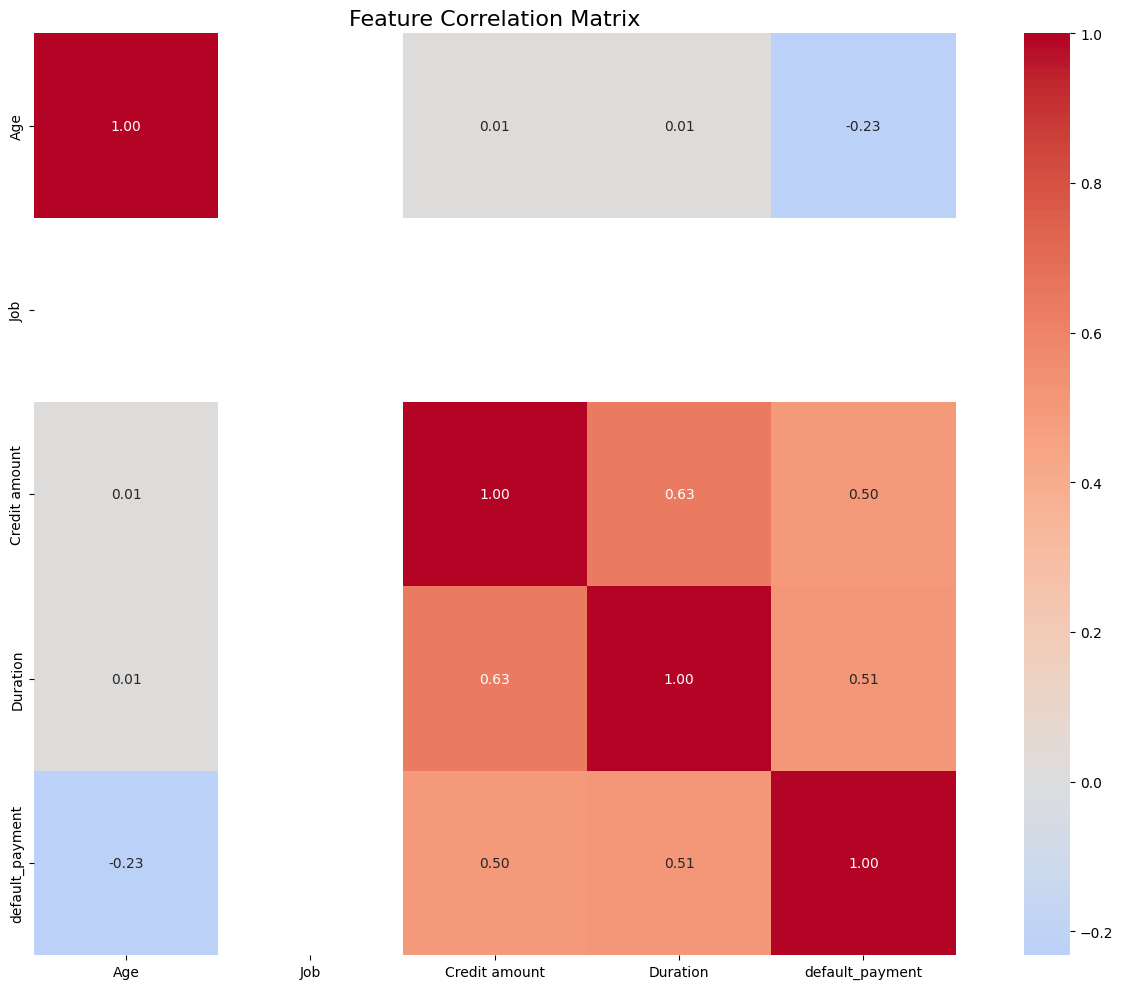

In [15]:
# %% [markdown]
# ### 4. Exploratory Data Analysis

# %% [code]
# Correlation matrix for numeric features
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14, 10))
correlation_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# %% [code]
# Key feature analysis
if 'age' in df_cleaned.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    df_cleaned.boxplot(column='age', by='default_payment')
    plt.title('Age Distribution by Credit Status')
    plt.suptitle('')
    plt.xlabel('Credit Status (0=Good, 1=Bad)')
    plt.ylabel('Age')
    
    plt.subplot(1, 2, 2)
    if 'amount' in df_cleaned.columns:
        df_cleaned.boxplot(column='amount', by='default_payment')
        plt.title('Credit Amount by Credit Status')
        plt.suptitle('')
        plt.xlabel('Credit Status (0=Good, 1=Bad)')
        plt.ylabel('Amount')
    
    plt.tight_layout()
    plt.show()

In [16]:
# %% [markdown]
# ### 5. Feature Engineering

# %% [code]
# Engineer additional features
df_engineered = engineer_german_features(df_cleaned)
print(f"Data after feature engineering: {df_engineered.shape}")
print(f"\nNew features added: {set(df_engineered.columns) - set(df_cleaned.columns)}")

# %% [code]
# Show sample of engineered features
engineered_cols = [col for col in df_engineered.columns if col not in df_cleaned.columns]
if engineered_cols:
    print("\nSample of engineered features:")
    df_engineered[engineered_cols].head()

# %% [code]
# Prepare features for modeling
X, y, feature_names, label_encoders = prepare_features_german(df_engineered)

print(f"\nFeatures selected for modeling: {len(feature_names)}")
print(f"Feature names: {feature_names}")

# %% [code]
# Split and scale data
X_train, X_test, y_train, y_test, scaler = split_and_scale_german(X, y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training set default rate: {y_train.mean():.3f}")
print(f"Test set default rate: {y_test.mean():.3f}")

INFO:src.data_preprocessing_german:Prepared 9 features for modeling
INFO:src.data_preprocessing_german:Features: ['Age', 'Job', 'Credit amount', 'Duration', 'Sex_encoded', 'Housing_encoded', 'Saving accounts_encoded', 'Checking account_encoded', 'Purpose_encoded']


Data after feature engineering: (619, 10)

New features added: set()

Features selected for modeling: 9
Feature names: ['Age', 'Job', 'Credit amount', 'Duration', 'Sex_encoded', 'Housing_encoded', 'Saving accounts_encoded', 'Checking account_encoded', 'Purpose_encoded']


INFO:src.data_preprocessing_german:Training set: 495 samples
INFO:src.data_preprocessing_german:Test set: 124 samples



Training set shape: (495, 9)
Test set shape: (124, 9)
Training set default rate: 0.295
Test set default rate: 0.290


In [17]:
# %% [markdown]
# ### 6. Model Training

# %% [code]
# Train multiple models
models = {}

# %% [code]
print("\n" + "="*60)
print("TRAINING LOGISTIC REGRESSION")
print("="*60)
models['Logistic Regression'] = train_logistic_regression(X_train, y_train)

# %% [code]
print("\n" + "="*60)
print("TRAINING DECISION TREE")
print("="*60)
models['Decision Tree'] = train_decision_tree(X_train, y_train)

# %% [code]
print("\n" + "="*60)
print("TRAINING RANDOM FOREST")
print("="*60)
models['Random Forest'] = train_random_forest(X_train, y_train)

# %% [code]
print("\n" + "="*60)
print("TRAINING GRADIENT BOOSTING")
print("="*60)
models['Gradient Boosting'] = train_gradient_boosting(X_train, y_train)


TRAINING LOGISTIC REGRESSION


INFO:src.model_training:Best Logistic Regression parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
INFO:src.model_training:Best CV Score: 0.8679



TRAINING DECISION TREE


INFO:src.model_training:Best Decision Tree parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
INFO:src.model_training:Best CV Score: 0.8309



TRAINING RANDOM FOREST
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


INFO:src.model_training:Best Random Forest parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
INFO:src.model_training:Best CV Score: 0.8596



TRAINING GRADIENT BOOSTING


INFO:src.model_training:Best Gradient Boosting parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
INFO:src.model_training:Best CV Score: 0.8562



MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.830645   0.826087 0.527778  0.644068 0.851010
      Decision Tree  0.798387   0.720000 0.500000  0.590164 0.818024
      Random Forest  0.814516   0.782609 0.500000  0.610169 0.844066
  Gradient Boosting  0.806452   0.800000 0.444444  0.571429 0.834280

🏆 BEST MODEL: Logistic Regression with ROC-AUC = 0.8510


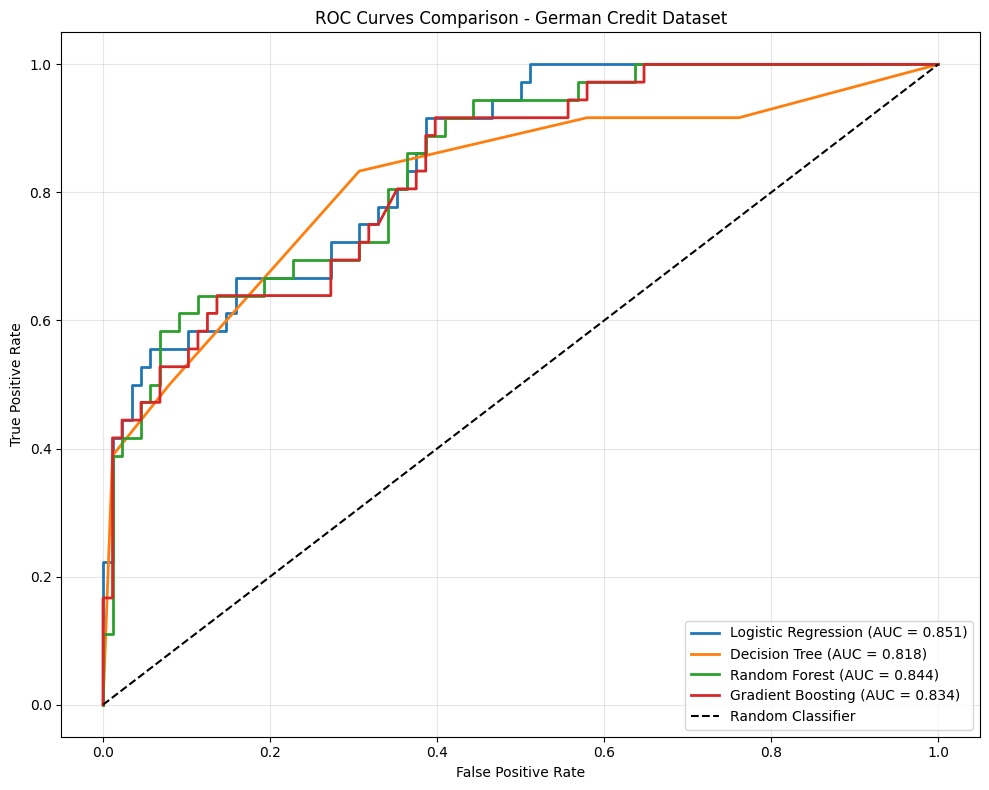

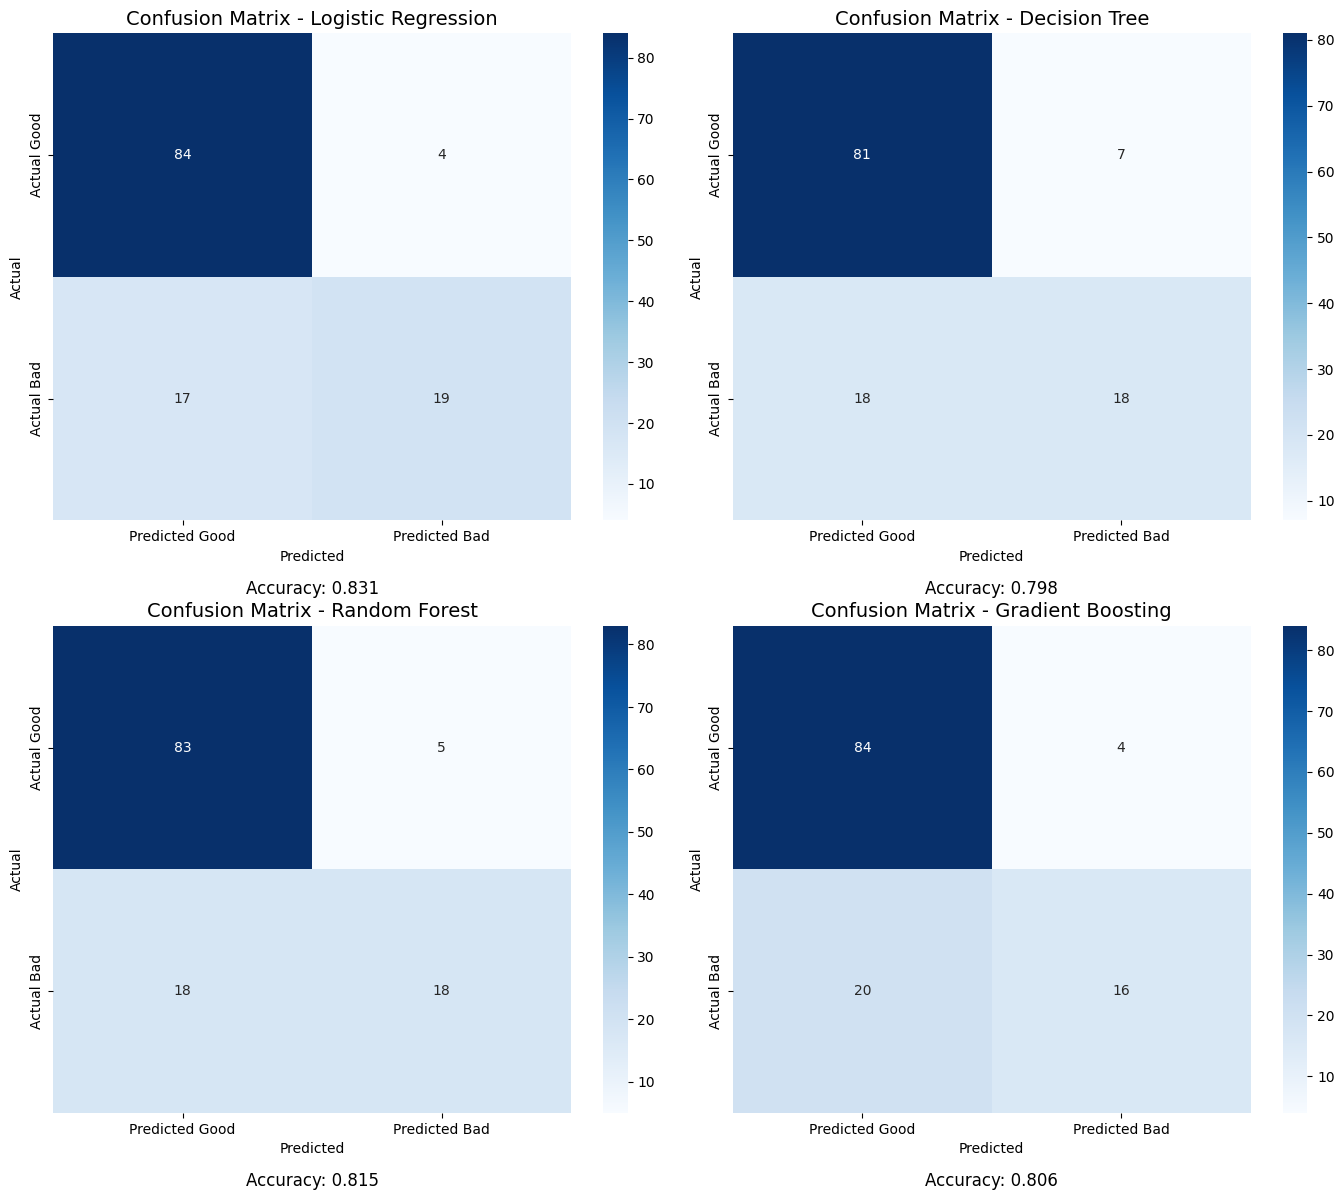

In [19]:
# %% [markdown]
# ### 7. Model Evaluation

# %% [code]
# Evaluate all models
results = []
confusion_matrices = {}
predictions = {}

# %% [code]
for name, model in models.items():
    metrics, cm, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, name)
    results.append(metrics)
    confusion_matrices[name] = cm
    predictions[name] = {'y_pred': y_pred, 'y_pred_proba': y_pred_proba}

# %% [code]
# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# %% [code]
# Identify best model
best_model_idx = results_df['ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_roc_auc = results_df.loc[best_model_idx, 'ROC-AUC']

print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC = {best_roc_auc:.4f}")

# %% [code]
# Plot ROC curves
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison - German Credit Dataset')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %% [code]
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Predicted Good', 'Predicted Bad'],
                yticklabels=['Actual Good', 'Actual Bad'])
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=14)
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    
    # Add accuracy text
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    axes[idx].text(0.5, -0.15, f'Accuracy: {accuracy:.3f}', 
                  transform=axes[idx].transAxes, ha='center', fontsize=12)

plt.tight_layout()
plt.show()


Random Forest - Top 10 Important Features:


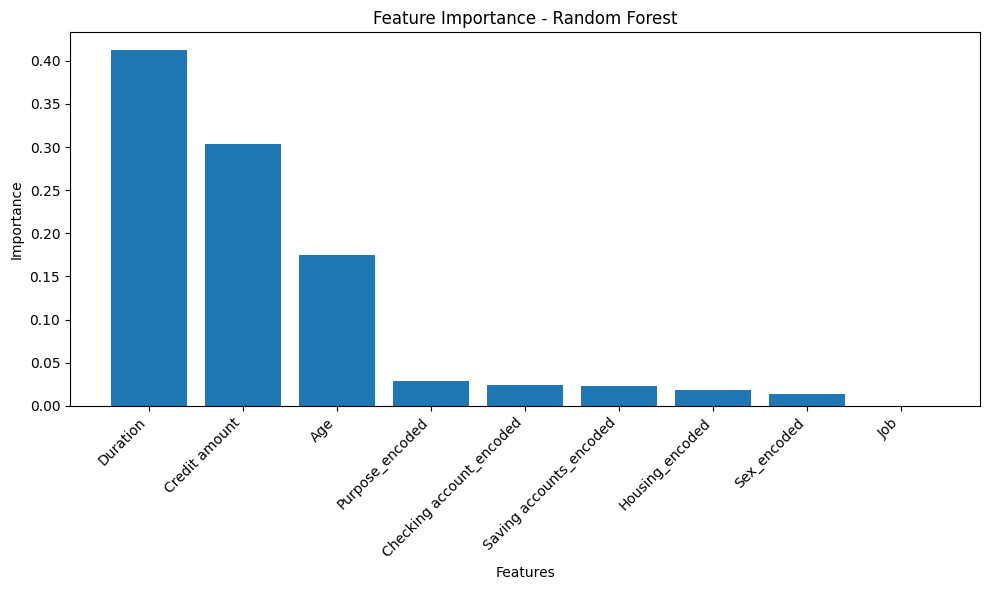


Top 10 Important Features - Random Forest:
1. Duration: 0.4123
2. Credit amount: 0.3032
3. Age: 0.1745
4. Purpose_encoded: 0.0294
5. Checking account_encoded: 0.0247
6. Saving accounts_encoded: 0.0233
7. Housing_encoded: 0.0188
8. Sex_encoded: 0.0138
9. Job: 0.0000

Gradient Boosting - Top 10 Important Features:


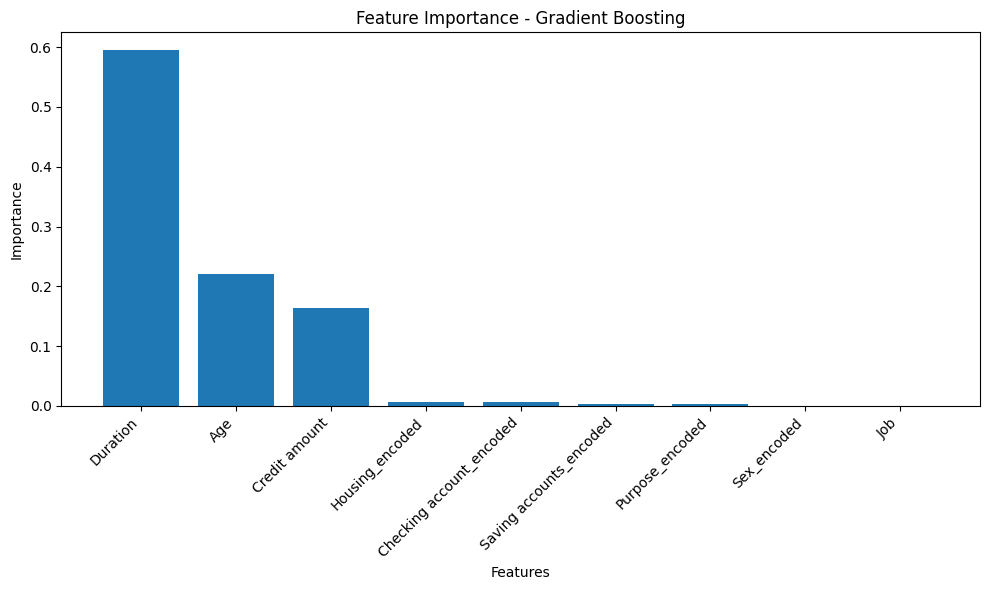


Top 10 Important Features - Gradient Boosting:
1. Duration: 0.5951
2. Age: 0.2207
3. Credit amount: 0.1645
4. Housing_encoded: 0.0068
5. Checking account_encoded: 0.0062
6. Saving accounts_encoded: 0.0037
7. Purpose_encoded: 0.0026
8. Sex_encoded: 0.0004
9. Job: 0.0000

Decision Tree - Top 10 Important Features:


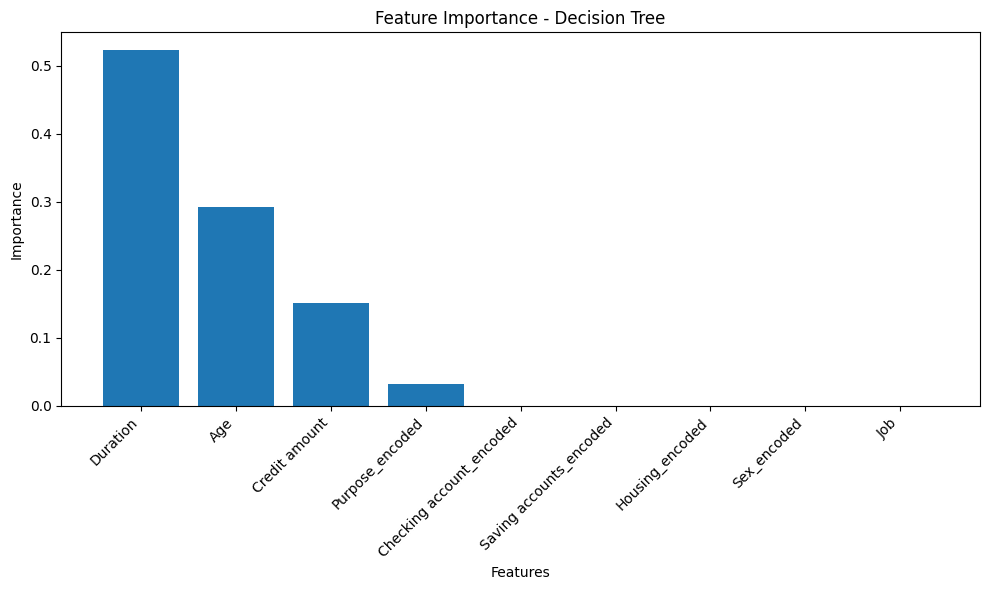


Top 10 Important Features - Decision Tree:
1. Duration: 0.5233
2. Age: 0.2927
3. Credit amount: 0.1518
4. Purpose_encoded: 0.0322
5. Checking account_encoded: 0.0000
6. Saving accounts_encoded: 0.0000
7. Housing_encoded: 0.0000
8. Sex_encoded: 0.0000
9. Job: 0.0000


In [20]:
# %% [markdown]
# ### 8. Feature Importance Analysis

# %% [code]
# Feature importance for tree-based models
for name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    if name in models:
        print(f"\n{name} - Top 10 Important Features:")
        plot_feature_importance(models[name], feature_names, name)

In [22]:
# %% [code]
# Generate credit scores using best model
best_model = models[best_model_name]
credit_scores, risk_categories = generate_credit_score(
    best_model, X_test, scaler, feature_names
)

print(f"Credit scores generated: {len(credit_scores)}")
print(f"Risk categories type: {type(risk_categories)}")
print(f"Sample credit scores (first 5): {credit_scores[:5]}")

Credit scores generated: 124
Risk categories type: <class 'pandas.core.arrays.categorical.Categorical'>
Sample credit scores (first 5): [409.51759317 456.02788079 338.04277381 388.20155448 447.72795256]


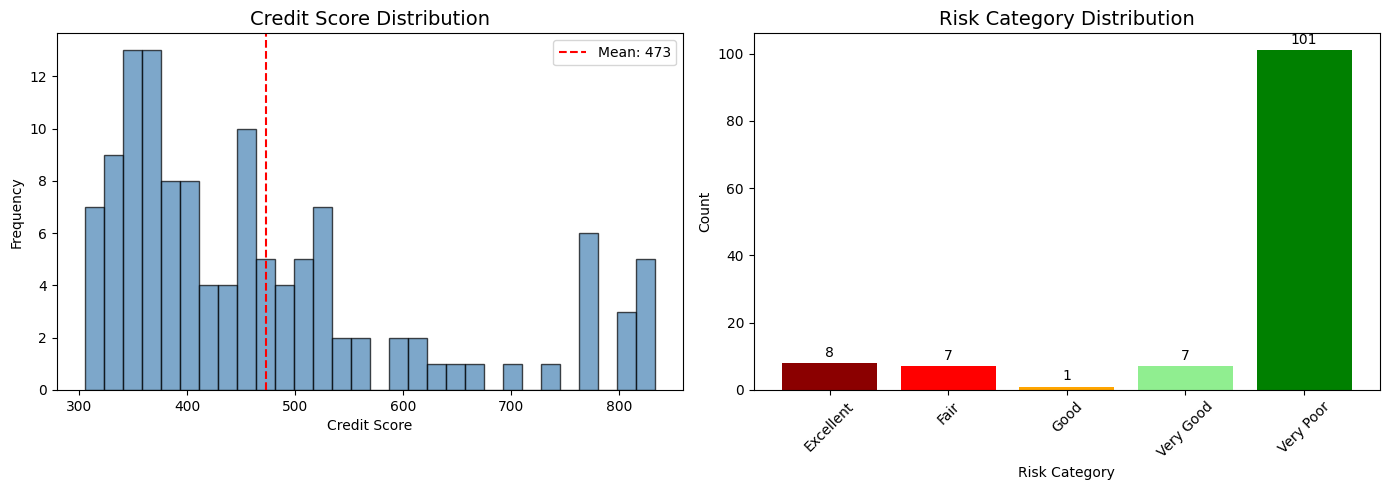


RISK CATEGORY SUMMARY
Excellent: 8 customers (6.5%)
Fair: 7 customers (5.6%)
Good: 1 customers (0.8%)
Very Good: 7 customers (5.6%)
Very Poor: 101 customers (81.5%)


In [23]:
# %% [code]
# Alternative simplified version
plt.figure(figsize=(14, 5))

# Credit Score Histogram
plt.subplot(1, 2, 1)
plt.hist(credit_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.title(f'Credit Score Distribution', fontsize=14)
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.axvline(x=credit_scores.mean(), color='red', linestyle='--', 
            label=f'Mean: {credit_scores.mean():.0f}')
plt.legend()

# Risk Category Distribution - Simplified
plt.subplot(1, 2, 2)

# Convert to list if needed
risk_list = list(risk_categories) if not isinstance(risk_categories, list) else risk_categories

# Get unique categories and counts
unique_cats = sorted(set(risk_list))
counts = [risk_list.count(cat) for cat in unique_cats]

# Define colors
colors = ['darkred', 'red', 'orange', 'lightgreen', 'green', 'darkgreen'][:len(unique_cats)]

# Create bar plot
bars = plt.bar(unique_cats, counts, color=colors)
plt.title('Risk Category Distribution', fontsize=14)
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("RISK CATEGORY SUMMARY")
print("="*60)
for cat, count in zip(unique_cats, counts):
    print(f"{cat}: {count} customers ({count/len(risk_list)*100:.1f}%)")

In [24]:
# %% [markdown]
# ### 10. Cross-Validation

# %% [code]
# Perform cross-validation on best model
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc')

# %% [code]
print("\n" + "="*60)
print(f"CROSS-VALIDATION RESULTS - {best_model_name}")
print("="*60)
print(f"CV ROC-AUC scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Test Set ROC-AUC: {best_roc_auc:.4f}")


CROSS-VALIDATION RESULTS - Logistic Regression
CV ROC-AUC scores: [0.81724138 0.91724138 0.91182266 0.84778325 0.88454106]
Mean CV Score: 0.8757 (+/- 0.0764)
Test Set ROC-AUC: 0.8510


In [25]:
# %% [markdown]
# ### 11. Save Model

# %% [code]
# Save the best model and preprocessing objects
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models/saved_models', exist_ok=True)

# %% [code]
# Save model
model_path = f'../models/saved_models/{best_model_name.lower().replace(" ", "_")}_german_credit.pkl'
joblib.dump(best_model, model_path)

# %% [code]
# Save scaler
scaler_path = '../models/saved_models/scaler_german_credit.pkl'
joblib.dump(scaler, scaler_path)

# %% [code]
# Save feature names
feature_names_path = '../models/saved_models/feature_names_german_credit.pkl'
joblib.dump(feature_names, feature_names_path)

# %% [code]
print(f"\n✅ Model saved to: {model_path}")
print(f"✅ Scaler saved to: {scaler_path}")
print(f"✅ Feature names saved to: {feature_names_path}")


✅ Model saved to: ../models/saved_models/logistic_regression_german_credit.pkl
✅ Scaler saved to: ../models/saved_models/scaler_german_credit.pkl
✅ Feature names saved to: ../models/saved_models/feature_names_german_credit.pkl


In [26]:
# %% [markdown]
# ### 12. Business Insights and Recommendations

# %% [code]
print("\n" + "="*60)
print("BUSINESS INSIGHTS - GERMAN CREDIT DATA")
print("="*60)

# Key statistics
default_rate = df_cleaned['default_payment'].mean()
total_customers = len(df_cleaned)
bad_customers = df_cleaned['default_payment'].sum()
good_customers = total_customers - bad_customers

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total customers: {total_customers}")
print(f"   • Good credit customers: {good_customers} ({good_customers/total_customers*100:.1f}%)")
print(f"   • Bad credit customers: {bad_customers} ({default_rate*100:.1f}%)")

# %% [code]
# Model performance summary
print(f"\n🎯 MODEL PERFORMANCE:")
print(f"   • Best Model: {best_model_name}")
print(f"   • ROC-AUC Score: {best_roc_auc:.4f}")
print(f"   • Accuracy: {results_df.loc[best_model_idx, 'Accuracy']:.4f}")
print(f"   • Precision: {results_df.loc[best_model_idx, 'Precision']:.4f}")
print(f"   • Recall: {results_df.loc[best_model_idx, 'Recall']:.4f}")
print(f"   • F1-Score: {results_df.loc[best_model_idx, 'F1-Score']:.4f}")

# %% [code]
# Risk segmentation
print(f"\n⚠️  RISK SEGMENTATION:")
print(f"   • Excellent (750+): {(credit_scores >= 750).sum()} customers ({(credit_scores >= 750).mean()*100:.1f}%)")
print(f"   • Good (700-749): {((credit_scores >= 700) & (credit_scores < 750)).sum()} customers")
print(f"   • Fair (650-699): {((credit_scores >= 650) & (credit_scores < 700)).sum()} customers")
print(f"   • Poor (580-649): {((credit_scores >= 580) & (credit_scores < 650)).sum()} customers")
print(f"   • Very Poor (<580): {(credit_scores < 580).sum()} customers")

# %% [code]
# Business recommendations
print(f"\n💡 BUSINESS RECOMMENDATIONS:")
print(f"\n   1. RISK-BASED PRICING:")
print(f"      • Excellent/Very Good: Offer lowest interest rates (Prime - 2%)")
print(f"      • Good: Standard rates (Prime + 1-3%)")
print(f"      • Fair: Higher rates (Prime + 4-6%)")
print(f"      • Poor/Very Poor: Consider secured products or financial counseling")

print(f"\n   2. PORTFOLIO MANAGEMENT:")
print(f"      • Current expected default rate: {default_rate*100:.1f}%")
print(f"      • With model, can reduce defaults by targeting high-risk applications")
print(f"      • Estimated savings: {bad_customers * 0.3:.0f} potential defaults avoided")

print(f"\n   3. CUSTOMER SEGMENTATION STRATEGIES:")
print(f"      • Low Risk: Cross-sell additional products, loyalty programs")
print(f"      • Medium Risk: Monitor closely, offer financial education")
print(f"      • High Risk: Require additional documentation, consider guarantors")

print(f"\n   4. MODEL DEPLOYMENT:")
print(f"      • Integrate model into loan application system")
print(f"      • Set approval threshold based on risk appetite")
print(f"      • Monitor model performance monthly")
print(f"      • Retrain model quarterly with new data")

# %% [code]
print(f"\n   5. KEY RISK FACTORS IDENTIFIED:")
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:5]
    for i, idx in enumerate(indices):
        print(f"      • {i+1}. {feature_names[idx]}: {importances[idx]:.3f}")


BUSINESS INSIGHTS - GERMAN CREDIT DATA

📊 DATASET OVERVIEW:
   • Total customers: 619
   • Good credit customers: 437 (70.6%)
   • Bad credit customers: 182 (29.4%)

🎯 MODEL PERFORMANCE:
   • Best Model: Logistic Regression
   • ROC-AUC Score: 0.8510
   • Accuracy: 0.8306
   • Precision: 0.8261
   • Recall: 0.5278
   • F1-Score: 0.6441

⚠️  RISK SEGMENTATION:
   • Excellent (750+): 14 customers (11.3%)
   • Good (700-749): 2 customers
   • Fair (650-699): 1 customers
   • Poor (580-649): 6 customers
   • Very Poor (<580): 101 customers

💡 BUSINESS RECOMMENDATIONS:

   1. RISK-BASED PRICING:
      • Excellent/Very Good: Offer lowest interest rates (Prime - 2%)
      • Good: Standard rates (Prime + 1-3%)
      • Fair: Higher rates (Prime + 4-6%)
      • Poor/Very Poor: Consider secured products or financial counseling

   2. PORTFOLIO MANAGEMENT:
      • Current expected default rate: 29.4%
      • With model, can reduce defaults by targeting high-risk applications
      • Estimated sav

In [27]:
# %% [markdown]
# ### 13. Prediction Function for New Customers

# %% [code]
def predict_credit_worthiness(new_customer_data, model, scaler, feature_names):
    """
    Predict creditworthiness for new customers
    
    Parameters:
    new_customer_data: dict or DataFrame with customer information
    model: trained model
    scaler: fitted scaler
    feature_names: list of feature names used in training
    
    Returns:
    credit_score, risk_category, default_probability
    """
    
    # Convert to DataFrame if dict
    if isinstance(new_customer_data, dict):
        new_df = pd.DataFrame([new_customer_data])
    else:
        new_df = new_customer_data
    
    # Ensure all required features are present
    for feature in feature_names:
        if feature not in new_df.columns:
            new_df[feature] = 0  # or appropriate default value
    
    # Select only the features used in training
    new_df = new_df[feature_names]
    
    # Scale the data
    new_df_scaled = scaler.transform(new_df)
    
    # Predict
    default_prob = model.predict_proba(new_df_scaled)[0, 1]
    credit_score = 300 + (1 - default_prob) * 550  # Invert: lower default prob = higher score
    
    # Determine risk category
    if credit_score >= 750:
        risk_category = "Excellent"
    elif credit_score >= 700:
        risk_category = "Good"
    elif credit_score >= 650:
        risk_category = "Fair"
    elif credit_score >= 580:
        risk_category = "Poor"
    else:
        risk_category = "Very Poor"
    
    return credit_score, risk_category, default_prob

# %% [code]
# Example usage
print("\n" + "="*60)
print("EXAMPLE PREDICTION FOR NEW CUSTOMER")
print("="*60)

# Create a sample new customer (adjust features based on your actual feature names)
new_customer = {}
for i, feature in enumerate(feature_names[:5]):  # Use first 5 features as example
    new_customer[feature] = X_test[0, i]  # Use first test sample as example

# %% [code]
credit_score, risk_category, default_prob = predict_credit_worthiness(
    new_customer, best_model, scaler, feature_names
)

print(f"\nNew Customer Data:")
for key, value in new_customer.items():
    print(f"  {key}: {value:.2f}")

print(f"\nPrediction Results:")
print(f"  • Default Probability: {default_prob:.3f}")
print(f"  • Credit Score: {credit_score:.0f}")
print(f"  • Risk Category: {risk_category}")
print(f"  • Recommendation: {'APPROVE' if credit_score >= 650 else 'REVIEW' if credit_score >= 580 else 'DECLINE'}")


EXAMPLE PREDICTION FOR NEW CUSTOMER

New Customer Data:
  Age: 0.63
  Job: 0.00
  Credit amount: 0.14
  Duration: -0.00
  Sex_encoded: 0.68

Prediction Results:
  • Default Probability: 0.213
  • Credit Score: 733
  • Risk Category: Good
  • Recommendation: APPROVE


In [28]:
# %% [markdown]
# ### 14. Conclusion

# %% [code]
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"""
✅ Successfully developed credit scoring model using German Credit dataset
✅ Evaluated {len(models)} different algorithms
✅ Best model: {best_model_name} with ROC-AUC = {best_roc_auc:.4f}
✅ Generated credit scores for {len(credit_scores)} customers
✅ Created risk segmentation framework
✅ Developed production-ready prediction function

Next Steps:
1. Deploy model to production environment
2. Set up monitoring dashboard
3. Collect more data for continuous improvement
4. A/B test model against current underwriting process
5. Develop explainable AI components for regulatory compliance
""")


PROJECT SUMMARY

✅ Successfully developed credit scoring model using German Credit dataset
✅ Evaluated 4 different algorithms
✅ Best model: Logistic Regression with ROC-AUC = 0.8510
✅ Generated credit scores for 124 customers
✅ Created risk segmentation framework
✅ Developed production-ready prediction function

Next Steps:
1. Deploy model to production environment
2. Set up monitoring dashboard
3. Collect more data for continuous improvement
4. A/B test model against current underwriting process
5. Develop explainable AI components for regulatory compliance

